SALES PERFORMANCE ANALYSIS

Analyzing historical sales data

1. BUSINESS PROBLEM:

-The objective of this project is to analyze historical sales data to identify key drivers of revenue, understand seasonal trends, and determine which products, regions, and customer segments contribute most to overall sales performance.

2. DATA OVERVIEW:

-The dataset contains historical daily sales data across multiple stores and product categories.
-Main variables include: Order Date -> transaction date, Ship Mode -> how the order was delivered, Category -> product identifier, Sales -> number of units sold.
-The dataset includes 9800 observations with 18 columns and appears to be suitable for time-series and performance analysis.

In [1]:
import pandas as pd
sales = pd.read_csv("C:/Users/user1/Desktop/Learn Python/Proiect 2 Sales Dataset/Superstore.csv", sep = ",")

sales.head()
#sales.shape

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


3. DATA CLEANING & PREPROCESSING:

Before performing the analysis, several preprocessing steps were applied like checking for missing values and confirming that the dataset contains no significant null entries, verifying data types for each column.

In [2]:
sales.info()
sales.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [3]:
sales.isnull().sum()
sales['Postal Code'] = sales['Postal Code'].fillna("Unknown")
sales.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [4]:
sales.duplicated().sum()

np.int64(0)

In [5]:
sales["Order Date"] = pd.to_datetime(sales["Order Date"], format = "%d/%m/%Y")

In [6]:
sales['Year'] = sales['Order Date'].dt.year
sales['Month'] = sales['Order Date'].dt.month
sales['Month Name'] = sales['Order Date'].dt.month_name()
sales['Day_of_Week'] = sales['Order Date'].dt.day_name()
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Day_of_Week
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,Wednesday
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,Wednesday
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,Monday
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,Tuesday
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,Tuesday


<Axes: >

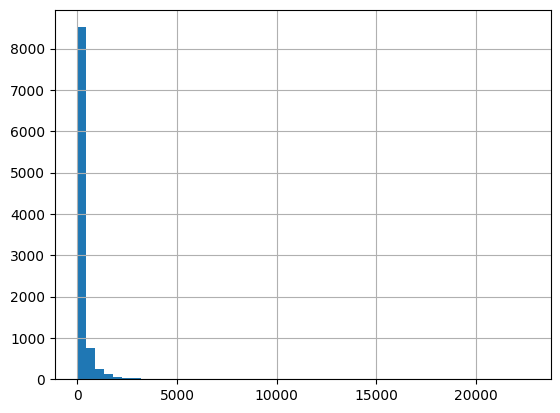

In [7]:
sales['Sales'].describe()
sales['Sales'].hist(bins = 50)

The "Sales" variable shows a highly right-skewed distribution, with a maximum value of 22.638 compared to a mean of 230. The histogram confirms the presence of extreme high-value outliers.

4. EXPLORATORY DATA ANALYSIS.

4.1. Sales trend evolution in time.

<Axes: xlabel='Year'>

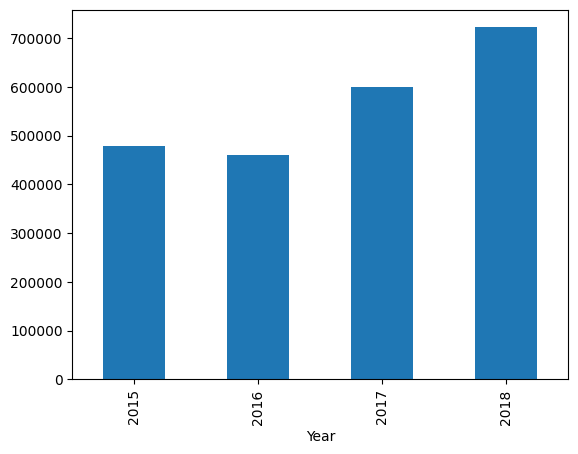

In [8]:
sales.groupby('Year')['Sales'].sum().plot(kind = "bar")

I can see that sales show an overall upward trend from 2015 to 2018, indicating business growth. However, there was a slight decline between 2015 and 2016 before growth resumed in the following years.

4.2. Monthly trend.

<Axes: xlabel='Month'>

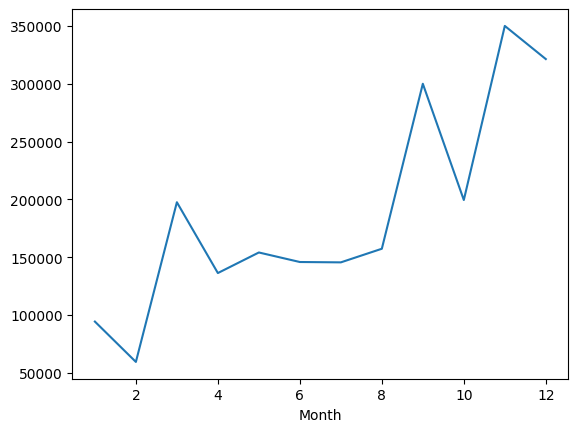

In [9]:
sales.groupby('Month')['Sales'].sum().plot(kind = "line")

Sales peak towards the end of the year, suggesting a strong seasonal effect, potentially driven by holiday shopping and promotional campaigns, altough additional data on campaigns would be needed to confirm this assumption.

4.3. Top performing categories.

In [10]:
sales.groupby('Category')['Sales'].sum().sort_values(ascending = False)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

Technology generates the highest revenue, suggesting strong market demand. However, revenue alone does not indicate profitability and to determine whether increasing production is a strategic decision, cost data would be required to know profit margins.

4.4. Regional performance.

In [11]:
sales.groupby('Region')['Sales'].sum().sort_values(ascending = False)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

The western and eastern regions account for the highest sales, indicating they are currently the most profitable markets. However, the central and south regions contribute less, but represent potential growth opportunities if targeted marketing or pricing adjustments.

4.5. Customer segment analysis.

In [12]:
sales.groupby('Segment')['Sales'].sum().sort_values(ascending = False)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

The consumer segment generates the highest total sales, significantly outperforming the corporate and home office segments. This indicates that individual customers represent the primary revenue driver for the business and better marketing strategies and promotions could therefore be focused on this segment.

4.6. Shipping mode analysis.

<Axes: xlabel='Ship Mode'>

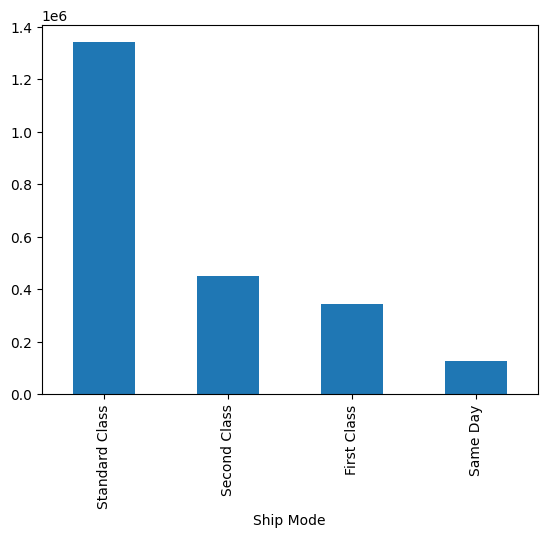

In [13]:
sales.groupby('Ship Mode')['Sales'].sum().sort_values(ascending = False).plot(kind = 'bar')

Standard class accounts for the largest share of total sales, significantly outperforming faster shipping options such as first class and same day delivery. This obvious dominance suggests that customers prefer the lower cost option.

5. SUMMARY OF EXPLORATORY DATA ANALYSIS

-Sales show an overall upward trend from 2015 to 2018, indicating consistent business growth;
-Sales peak toward the end of the year, suggesting strong seasonal demand during holiday periods;
-Technology products generate the highest revenue among all product categories;
-The western and eastern regions are contributing with the largest share of total sales;
-The consumer segment represents the main source of revenue for the business;
-The cheapest class ("Standard Class") is the mosy frequently used shipping mode.

6. PREDICTIVE MODELING

6.1. Feature engineering.

In this step, I only kept the relevant columns from the dataset.

In [14]:
sales_ml = sales.drop(['Row ID', 'Order ID', 'Customer ID', 'Customer Name',\
     'Product Name', 'Ship Date', 'Order Date'], axis = 1)
sales_ml

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Sales,Year,Month,Month Name,Day_of_Week
0,Second Class,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,261.9600,2017,11,November,Wednesday
1,Second Class,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,731.9400,2017,11,November,Wednesday
2,Second Class,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,14.6200,2017,6,June,Monday
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,957.5775,2016,10,October,Tuesday
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,22.3680,2016,10,October,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,Standard Class,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,3.7980,2017,5,May,Sunday
9796,Standard Class,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,10.3680,2016,1,January,Tuesday
9797,Standard Class,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,235.1880,2016,1,January,Tuesday
9798,Standard Class,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,26.3760,2016,1,January,Tuesday


6.2. Encoding using One-Hot Encoding.

In [15]:
sales_ml = pd.get_dummies(sales_ml, drop_first = True)
sales_ml

,Sales,Year,Month,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,City_Abilene,City_Akron,...,Month Name_May,Month Name_November,Month Name_October,Month Name_September,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday
0,261.9600,2017,11,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
1,731.9400,2017,11,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
2,14.6200,2017,6,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,957.5775,2016,10,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
4,22.3680,2016,10,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,3.7980,2017,5,False,False,True,True,False,False,False,...,True,False,False,False,False,False,True,False,False,False
9796,10.3680,2016,1,False,False,True,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9797,235.1880,2016,1,False,False,True,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9798,26.3760,2016,1,False,False,True,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False


6.3. Defining X and Y variables (Y target -> Sales).

In [16]:
X = sales_ml.drop('Sales', axis = 1)
Y = sales_ml['Sales']

6.4. Train-Test split.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, \
    random_state = 42)

6.5. Linear regression model.

In [18]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
Y_pred_lr =  lr.predict(X_test)

In [31]:
from sklearn.metrics import r2_score, mean_squared_error
print("R^2:",r2_score(Y_test, Y_pred_lr))
print("MSE:",mean_squared_error(Y_test, Y_pred_lr))

R^2: 0.3586201925324114
MSE: 428698.13622899883


-The Linear Regression model achieved an R^2 score of 0.3586 and a Mean Squared Error (MSE) of approximately 428,698.

-An R^2 score of 0.3586 indicates that the model explains about 36% of the variance in sales based on the available features. While this shows that the model captures some patterns in the data, a large portion of the variation in sales remains unexplained.

-This is expected since sales are influenced by many additional factors such as promotions, seasonality and pricing strategies that are not included in this dataset.

6.6. Random forest model.

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state = 42)
rf.fit(X_train, Y_train)
y_pred_rf = rf.predict(X_test)

In [30]:
print("R^2:", r2_score(Y_test, y_pred_rf))
print("MSE:", mean_squared_error(Y_test, y_pred_rf))

R^2: 0.3248699113144109
MSE: 451256.81750786427


-The Random Forest regressor was used to capture potentially more complex non-linear relationships in the dataset.

-However, the model produced performance metrics similar to the Linear one, with an R^2 score of 0,3248 and a MSE close to that of the baseline model.

-This suggests that the available features do not provide enough predictive information to significantly improve the model's performance and we can fix this by adding more relevant variables, such as product price, quantity sold or promotional campaigns.

7. FINAL CONCLUSION

This project explored sales patterns using exploratory data analysis and basic machine learning models.

Through EDA, several key insights were identified, like:
-Sales increased overall between 2015 and 2018;
-Sales tend to peak toward the end of the year, likely due to seasonal events;
-The technology category generates the highest revenue;
-The consumer segment contributes the largest share of total sales.

Two regression models were tested to predict sales and both achieved similar performance because of limited available features that can explain variance in sales. Potential variables such as product pricing, quantity sold and marketing campaigns could improve predictive performance.

Overall, the project demonstrates the use of exploratory data analysis and basic machine learning techniques to better understand and model sales behavior. Also, it demonstrates the importance of relevant variables to help us predict more accurately the target variable.